# **3. Análisis Exploratorio de Datos**

**Estructura del dataset:**
```
brisc2025/
└── segmentation_task/
    ├── train/
    │   ├── images/
    │   └── masks/
    └── test/
        ├── images/
        └── masks/
```

## 3.1 Librerias

In [72]:
import os
import re
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_style('whitegrid')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3.2 Distribución estructural del dataset

### 3.2.1 Carga y validación de datos de segmentación

En esta sección se cargan las imágenes y máscaras correspondientes a la tarea de segmentación. Se valida la consistencia entre ambos conjuntos de datos, asegurando que cada imagen tenga una máscara asociada con el mismo identificador.

In [73]:
base_path = r"C:\Users\johan\OneDrive - Universidad del Norte\Escritorio\Proyectos academicos\imagenes_tumores_cerebrales\brisc2025"

In [74]:
train_images_path = os.path.join(base_path, "segmentation_task", "train", "images")
train_masks_path  = os.path.join(base_path, "segmentation_task", "train", "masks")

In [75]:
test_images_path = os.path.join(base_path, "segmentation_task", "test", "images")
test_masks_path  = os.path.join(base_path, "segmentation_task", "test", "masks")

In [76]:
train_images = sorted(os.listdir(train_images_path))
train_masks  = sorted(os.listdir(train_masks_path))

test_images = sorted(os.listdir(test_images_path))
test_masks  = sorted(os.listdir(test_masks_path))

print("Train imágenes:", len(train_images))
print("Train máscaras:", len(train_masks))

print("Test imágenes:", len(test_images))
print("Test máscaras:", len(test_masks))

Train imágenes: 3933
Train máscaras: 3933
Test imágenes: 860
Test máscaras: 860


### 3.2.2 Construcción del DataFrame base

Se construye un DataFrame unificado que contiene los nombres de archivo y la partición correspondiente (train/test), permitiendo un manejo estructurado del dataset para análisis posteriores.

In [77]:
train_img_names = [f.replace(".jpg", "") for f in train_images]
train_mask_names = [f.replace(".png", "") for f in train_masks]

print("Train match:", train_img_names == train_mask_names)


test_img_names = [f.replace(".jpg", "") for f in test_images]
test_mask_names = [f.replace(".png", "") for f in test_masks]

print("Test match:", test_img_names == test_mask_names)

Train match: True
Test match: True


In [78]:
train_df = pd.DataFrame({
    "filename": train_images,
    "split": "train"
})

test_df = pd.DataFrame({
    "filename": test_images,
    "split": "test"
})

df = pd.concat([train_df, test_df], ignore_index=True)

df.head()

,filename,split
0,brisc2025_train_00001_gl_ax_t1.jpg,train
1,brisc2025_train_00002_gl_ax_t1.jpg,train
2,brisc2025_train_00003_gl_ax_t1.jpg,train
3,brisc2025_train_00004_gl_ax_t1.jpg,train
4,brisc2025_train_00005_gl_ax_t1.jpg,train


### 3.2.3 Extracción de metadatos desde los nombres de archivo

A partir de la convención de nombres del dataset, se extrae información relevante como el tipo de tumor, el plano de adquisición y la secuencia de imagen. Este proceso permite enriquecer el DataFrame con variables clave para el análisis exploratorio.

In [79]:
def parse_filename(filename):
    parts = filename.replace(".jpg", "").split("_")
    
    return pd.Series({
        "tumor": parts[3],
        "view": parts[4],
        "sequence": parts[5]
    })

metadata = df["filename"].apply(parse_filename)

df = pd.concat([df, metadata], axis=1)

df.head()

,filename,split,tumor,view,sequence
0,brisc2025_train_00001_gl_ax_t1.jpg,train,gl,ax,t1
1,brisc2025_train_00002_gl_ax_t1.jpg,train,gl,ax,t1
2,brisc2025_train_00003_gl_ax_t1.jpg,train,gl,ax,t1
3,brisc2025_train_00004_gl_ax_t1.jpg,train,gl,ax,t1
4,brisc2025_train_00005_gl_ax_t1.jpg,train,gl,ax,t1


In [80]:
df["tumor"].unique(), df["view"].unique()

(array(['gl', 'me', 'pi'], dtype=object),
 array(['ax', 'co', 'sa'], dtype=object))

**Nota:** El dataset de segmentación incluye únicamente imágenes con presencia de tumor, excluyendo la clase "no tumor", ya que estas no cuentan con máscaras asociadas.

### 3.2.4 Distribución por tipo de tumor

Se analiza la distribución de las imágenes según el tipo de tumor presente, con el fin de identificar posibles desbalances entre clases que puedan influir en el entrenamiento del modelo.

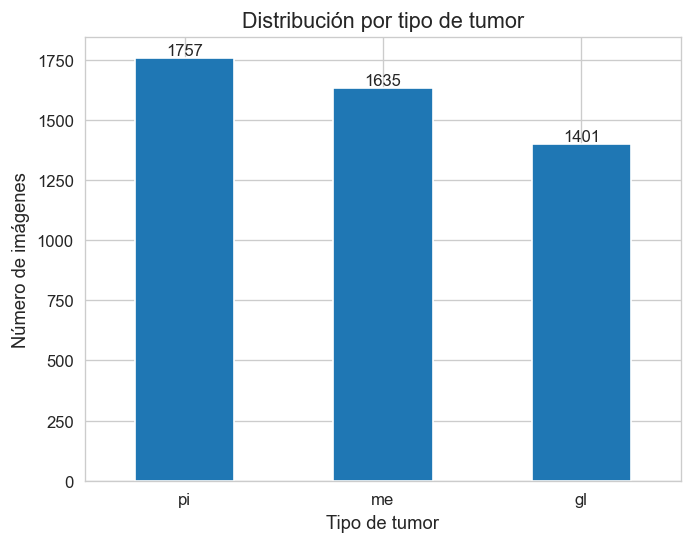

In [81]:
tumor_counts = df["tumor"].value_counts()

plt.figure()
ax = tumor_counts.plot(kind='bar')

plt.title("Distribución por tipo de tumor")
plt.xlabel("Tipo de tumor")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0])

plt.show()

El dataset muestra una distribución bastante equilibrada entre las tres categorías de tumores. Al revisar los números, la clase **pituitary** lidera con 1,757 imágenes, seguida de cerca por **meningioma** con 1,635, mientras que **glioma** cuenta con 1,401 muestras.

Aunque hay una diferencia natural en el volumen de datos entre cada tipo, las proporciones son lo suficientemente cercanas como para considerar que el conjunto de datos es sólido. Esta paridad es un buen punto de partida para el análisis, ya que garantiza que cada patología tenga una representación clara en el dataset y permite identificar las características visuales de cada tumor sin que una clase opaque completamente a las demás.

### 3.2.5 Distribución por plano de adquisición

Se analiza la distribución de las imágenes según el plano de adquisición (axial, coronal y sagital), con el objetivo de evaluar la representatividad de cada vista en el dataset.

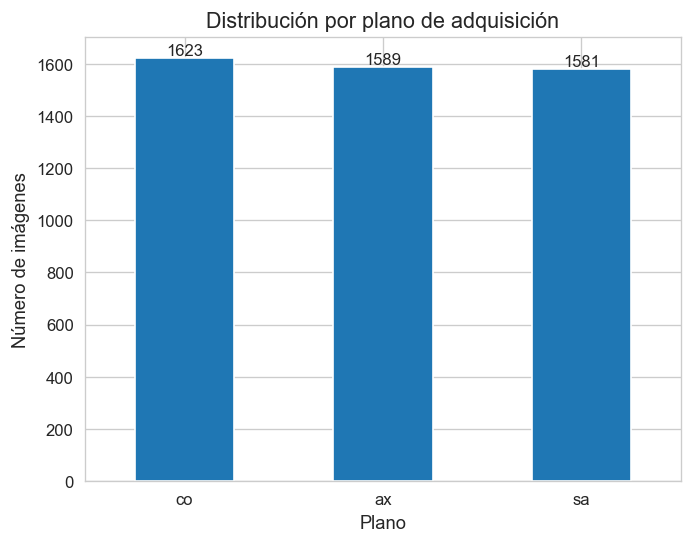

In [82]:
view_counts = df["view"].value_counts()

plt.figure()
ax = view_counts.plot(kind='bar')

plt.title("Distribución por plano de adquisición")
plt.xlabel("Plano")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)

ax.bar_label(ax.containers[0])

plt.show()

Al analizar la distribución por plano de adquisición, se confirma que el dataset mantiene una proporción casi simétrica entre las tres orientaciones anatómicas. Los registros se distribuyen de forma muy uniforme: **el plano coronal cuenta con 1,623 imágenes**, seguido del **axial con 1,589** y **el sagital con 1,581**.

Esta paridad es un hallazgo clave para los objetivos del proyecto, ya que garantiza que el modelo sea expuesto a una cantidad equivalente de información morfológica desde cada perspectiva. Al no existir un sesgo hacia un plano específico, contamos con una base sólida para desarrollar una de  las contribuciones diferenciadoras de este trabajo: el análisis de rendimiento desagregado por plano anatómico. Esto permitirá evaluar con rigor científico si la arquitectura propuesta generaliza con la misma precisión en cortes horizontales, frontales y laterales.

### 3.2.6 Distribución conjunta: tipo de tumor vs plano de adquisición

Se analiza la distribución conjunta entre el tipo de tumor y el plano de adquisición, con el objetivo de identificar posibles sesgos estructurales en el dataset que puedan influir en el desempeño del modelo según la combinación de clase y vista anatómica.

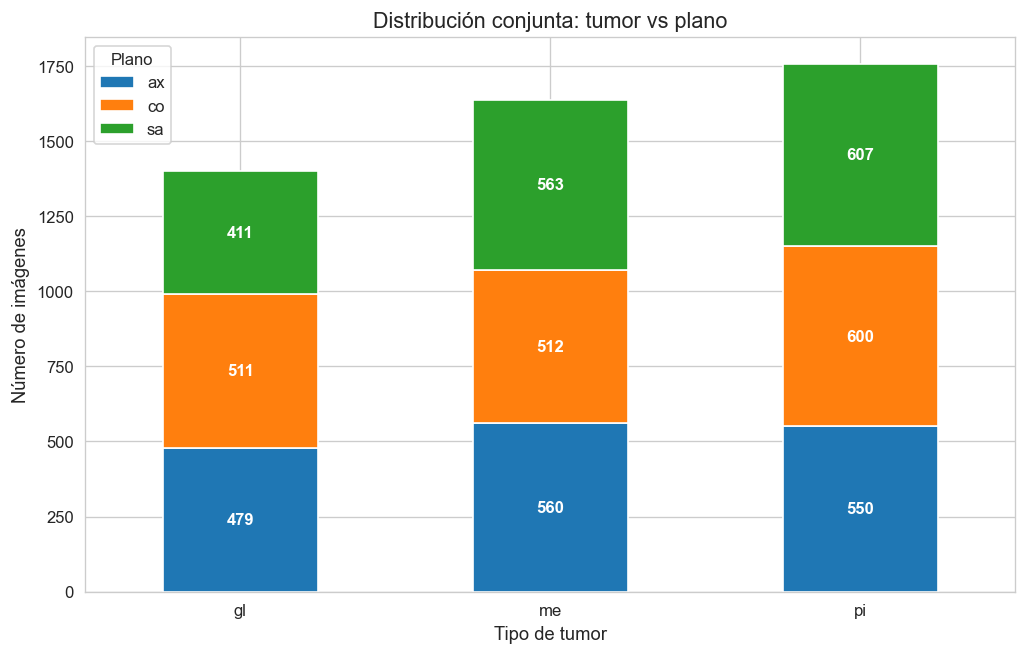

In [83]:
cross_tab = pd.crosstab(df["tumor"], df["view"])

ax = cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Distribución conjunta: tumor vs plano")
plt.xlabel("Tipo de tumor")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.legend(title="Plano")

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontweight='bold', color='white')

plt.show()

El análisis conjunto entre el tipo de tumor y el plano de adquisición evidencia una distribución altamente uniforme entre ambas variables. En particular, cada clase tumoral se encuentra representada de manera equilibrada en los tres planos anatómicos, sin concentraciones evidentes en una orientación específica.

Por ejemplo, la clase *pituitary* (1,757 imágenes) presenta una distribución homogénea entre los planos axial (550), coronal (600) y sagital (607). De manera similar, las clases *meningioma* y *glioma* mantienen proporciones consistentes entre vistas, con variaciones menores que no sugieren un sesgo estructural significativo.

Este comportamiento indica que no existe una dependencia aparente entre el tipo de tumor y el plano de adquisición, lo cual es deseable para el entrenamiento de modelos de segmentación. En particular, esta propiedad permite evaluar la capacidad de generalización del modelo en diferentes orientaciones anatómicas sin que los resultados estén condicionados por desbalances en la distribución de los datos.

## 3.3 Visualización inicial del dataset

Con el fin de comprender la naturaleza de los datos, se presentan ejemplos representativos de imágenes de resonancia magnética junto con sus respectivas máscaras de segmentación. Esta visualización permite identificar la apariencia de los tumores, así como la variabilidad asociada a los diferentes planos de adquisición.

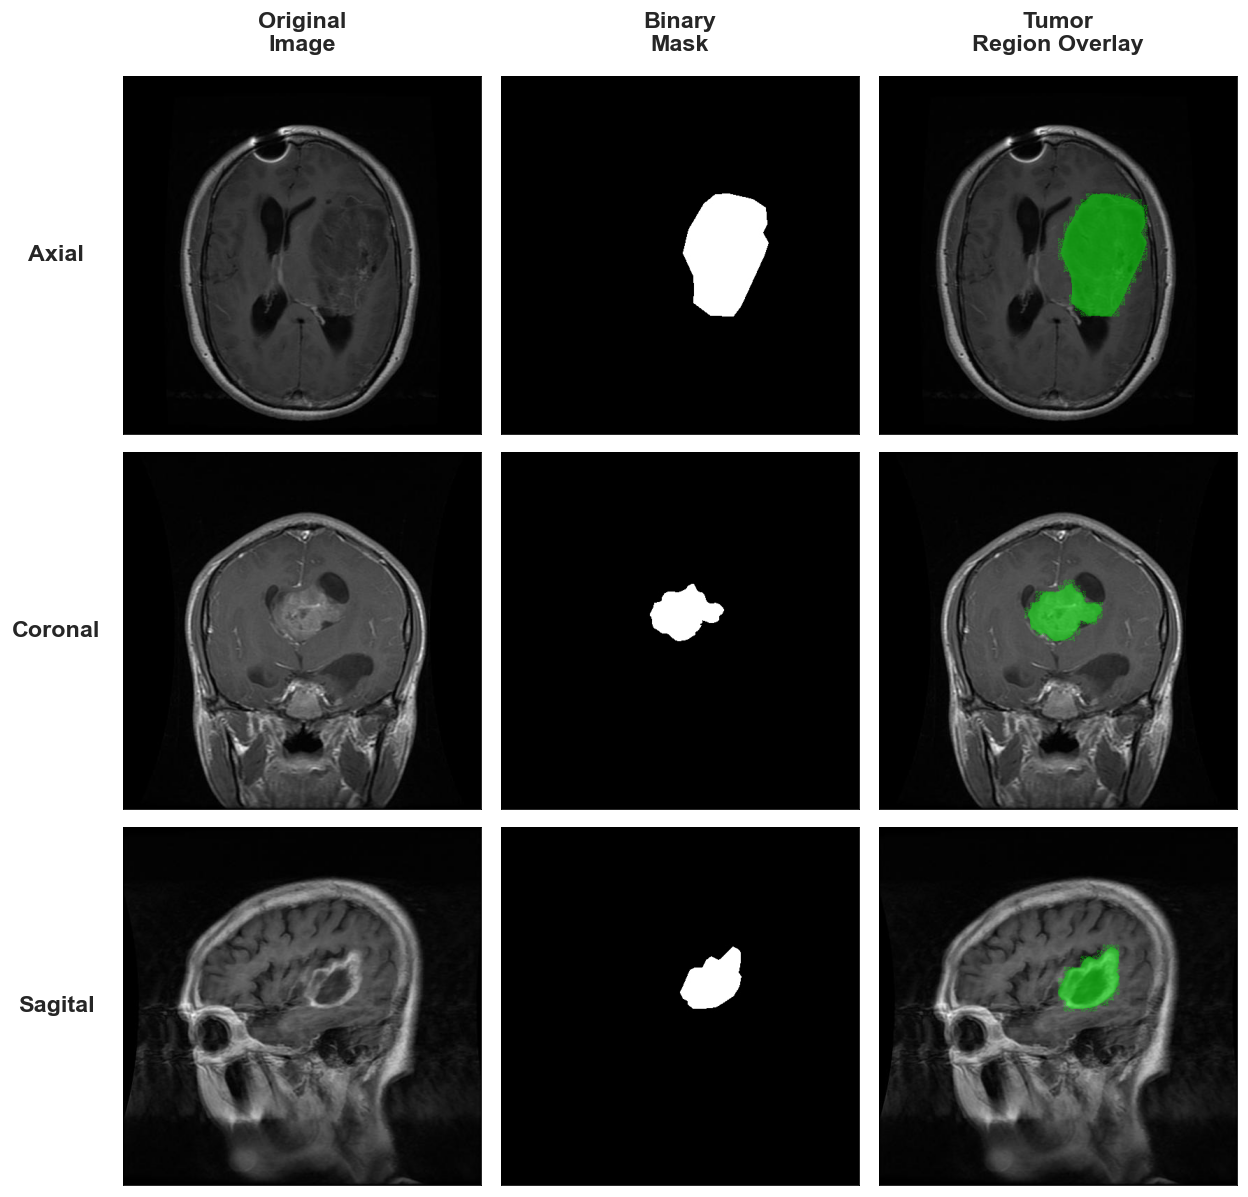

In [84]:
PLANE_MAP = {'ax': 'Axial', 'co': 'Coronal', 'sa': 'Sagital'}

def load_scan_pair(row, base_path):
    split = row["split"]
    filename = row["filename"]
    
    img_path = os.path.join(base_path, "segmentation_task", split, "images", filename)
    mask_name = filename.replace(".jpg", ".png")
    mask_path = os.path.join(base_path, "segmentation_task", split, "masks", mask_name)
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    return image, mask

samples = {
    'ax': df[df["view"] == "ax"].iloc[1],
    'co': df[df["view"] == "co"].iloc[1],
    'sa': df[df["view"] == "sa"].iloc[1]
}

fig, axes = plt.subplots(3, 3, figsize=(12, 12), gridspec_kw={'wspace':0.05, 'hspace':0.05})

col_titles = ["Original\nImage", "Binary\nMask", "Tumor\nRegion Overlay"]
planos = ['ax', 'co', 'sa']

for i, plano_code in enumerate(planos):
    
    row = samples[plano_code]
    image, mask = load_scan_pair(row, base_path)
    
    overlay = image.copy()
    
    tumor_mask = mask > 0
    
    overlay[tumor_mask] = [0, 255, 0]
    
    
    axes[i, 0].imshow(image)
    
    axes[i, 1].imshow(mask, cmap='gray')
    
    axes[i, 2].imshow(image)
    axes[i, 2].imshow(overlay, alpha=0.5)
    
    if i == 0:
        for j, title in enumerate(col_titles):
            axes[i, j].set_title(title, fontsize=14, fontweight='bold', pad=15)
            
    axes[i, 0].set_ylabel(PLANE_MAP[plano_code], rotation=0, fontsize=14, fontweight='bold', labelpad=40, va='center')
    
    for j in range(3):
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        for spine in axes[i, j].spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()

A partir de la visualización de ejemplos representativos en los tres planos de adquisición (axial, coronal y sagital), se pueden identificar varias características relevantes del dataset.

En primer lugar, las máscaras de segmentación muestran una correspondencia precisa con las regiones tumorales observables en las imágenes originales, lo que sugiere una alta calidad en las anotaciones. Las regiones marcadas se encuentran bien delimitadas y presentan coherencia espacial con las estructuras anatómicas circundantes.

Asimismo, se observa una variabilidad significativa en el tamaño, forma y localización de los tumores. Mientras que en algunos casos las regiones tumorales son pequeñas y focalizadas (como en el plano axial), en otros presentan extensiones más amplias y complejas (como en el plano coronal). Esta heterogeneidad incrementa la dificultad del problema de segmentación, ya que el modelo deberá ser capaz de adaptarse a diferentes patrones morfológicos.

Adicionalmente, las diferencias entre planos evidencian que la apariencia del tumor puede cambiar considerablemente dependiendo de la orientación anatómica. En el plano sagital, por ejemplo, se observan estructuras más fragmentadas, mientras que en el plano coronal las regiones tumorales tienden a ser más continuas y definidas.

En conjunto, estas observaciones confirman que el problema de segmentación presenta una complejidad significativa, tanto por la variabilidad intra-clase como por las diferencias entre planos, lo que justifica el uso de modelos de deep learning capaces de capturar características espaciales complejas.

### 3.4 Análisis de dimensiones de imagen

Se analiza la distribución de las dimensiones de las imágenes con el fin de identificar posibles variaciones en el tamaño que puedan afectar el diseño del pipeline de preprocesamiento y el entrenamiento del modelo.

In [85]:
heights = []
widths = []

for idx, row in df.iterrows():
    path = os.path.join(base_path, "segmentation_task", row["split"], "images", row["filename"])
    
    img = cv2.imread(path)
    
    h, w = img.shape[:2]
    
    heights.append(h)
    widths.append(w)

In [86]:
len(heights), len(widths)

(4793, 4793)

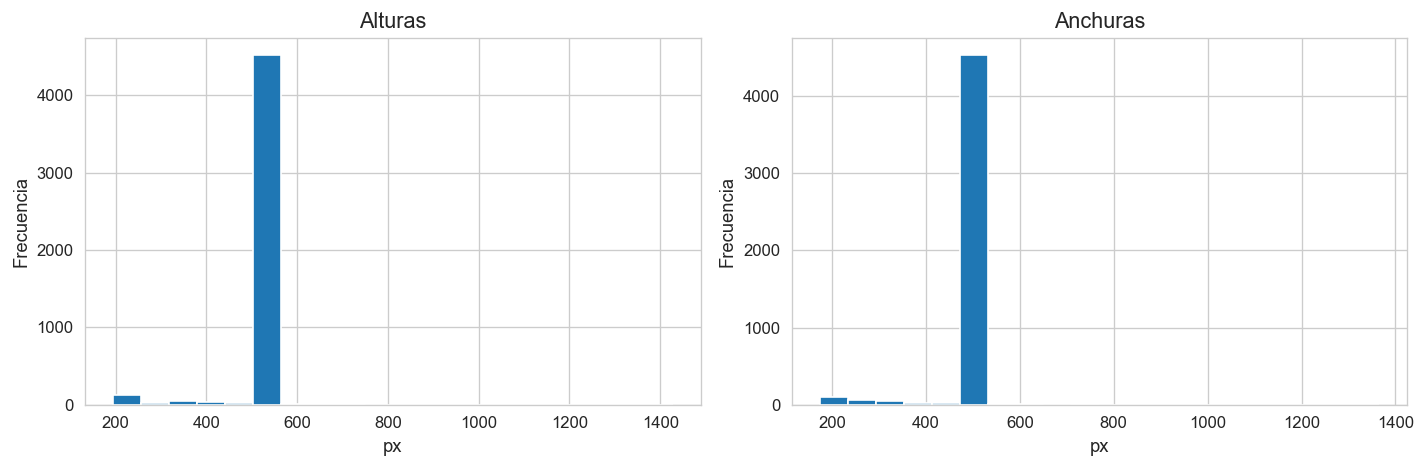

In [87]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(heights, bins=20)
plt.title("Alturas")
plt.xlabel("px")
plt.ylabel("Frecuencia")

plt.subplot(1,2,2)
plt.hist(widths, bins=20)
plt.title("Anchuras")
plt.xlabel("px")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

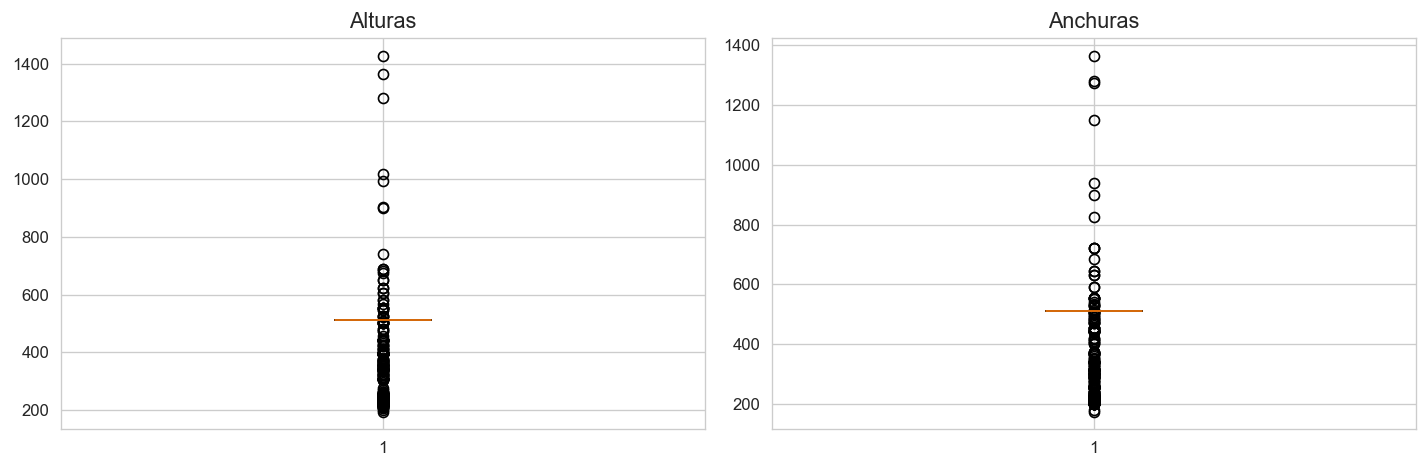

In [88]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.boxplot(heights)
plt.title("Alturas")

plt.subplot(1,2,2)
plt.boxplot(widths)
plt.title("Anchuras")

plt.tight_layout()
plt.show()

Los gráficos revelan una **heterogeneidad significativa** en las dimensiones de las imágenes del dataset BRISC 2025. A diferencia de otros datasets médicos que vienen pre-procesados a un tamaño fijo (como 512x512), aquí observamos lo siguiente:

1.  **Rango de Variabilidad:**
    * Las alturas (**Heights**) oscilan principalmente entre 200 y 600 píxeles, con picos notables cerca de los 400 y 500 px.
    * Las anchuras (**Widths**) muestran una dispersión similar, aunque con una concentración ligeramente distinta.
2.  **Implicaciones para el Modelo:**
    * **Resize Obligatorio:** Debido a que las redes neuronales convolucionales (CNN) y las arquitecturas tipo U-Net requieren un tensor de entrada de tamaño constante (ej. $256 \times 256$ o $512 \times 512$), será estrictamente necesario aplicar un paso de redimensionamiento en el preprocesamiento.
    * **Aspect Ratio (Relación de Aspecto):** Al observar que no hay un único punto de coincidencia, es probable que muchas imágenes no sean perfectamente cuadradas. Esto implica que al redimensionar, debemos decidir si aplicamos un *padding* (relleno) para mantener la proporción o si hacemos un *resize* directo, asumiendo una ligera deformación anatómica.


### 3.5 Análisis de la proporción del área tumoral

En tareas de segmentación médica, uno de los desafíos más críticos es el **desbalance de clases a nivel de píxel**. A diferencia de la clasificación de imágenes, donde el desbalance se mide en cantidad de muestras, en segmentación debemos medir qué fracción de la imagen corresponde realmente al objeto de interés (el tumor) frente al fondo (tejido sano y espacio vacío).

Este análisis es fundamental por dos razones:
1.  **Justificación de la Función de Pérdida:** Si el tumor ocupa un porcentaje muy pequeño de la imagen (por ejemplo, menos del 5%), una función de pérdida convencional como *Binary Cross-Entropy* puede fallar, ya que el modelo podría alcanzar una precisión engañosa del 95% simplemente prediciendo que todo es fondo. Esto justifica técnicamente el uso de funciones como **Dice Loss** o **IoU Loss**.
2.  **Dificultad Intrínseca:** Permite identificar si ciertas clases (como los gliomas en planos específicos) son sistemáticamente más pequeñas y, por ende, más difíciles de segmentar.

En esta sección, calcularemos el **Tumor Area Ratio**, definido como la proporción de píxeles pertenecientes a la lesión frente al total de píxeles de la imagen.

In [89]:
def calculate_tumor_area_ratio(row, base_path):
    split = row["split"]
    mask_name = row["filename"].replace(".jpg", ".png")
    mask_path = os.path.join(base_path, "segmentation_task", split, "masks", mask_name)
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if mask is None:
        return 0.0
    
    tumor_pixels = np.count_nonzero(mask)
    total_pixels = mask.shape[0] * mask.shape[1]
    
    return (tumor_pixels / total_pixels) * 100

df["tumor_area_percentage"] = df.apply(lambda row: calculate_tumor_area_ratio(row, base_path), axis=1)

print("\nEstadísticas generales del área del tumor (%):")
print(df["tumor_area_percentage"].describe())

print("\nPromedio de área por tipo de tumor:")
print(df.groupby("tumor")["tumor_area_percentage"].mean())


Estadísticas generales del área del tumor (%):
count    4793.000000
mean        1.885059
std         1.594635
min         0.041199
25%         0.839615
50%         1.428604
75%         2.363968
max        19.609367
Name: tumor_area_percentage, dtype: float64

Promedio de área por tipo de tumor:
tumor
gl    2.056075
me    2.478362
pi    1.196589
Name: tumor_area_percentage, dtype: float64


El análisis de la proporción del área tumoral revela un escenario de **desbalance extremo de clases a nivel de píxel**, con un promedio general de ocupación de apenas **1.88%**. Esta característica es un indicador crítico de la dificultad de la tarea, ya que el modelo deberá discriminar estructuras de interés en imágenes donde el **98.12%** corresponde a fondo o tejido no patológico.

Al desglosar por patología, se observan variaciones morfológicas significativas:
* **Meningiomas (me):** Presentan la mayor extensión relativa, con un promedio de **2.48%**.
* **Gliomas (gl):** Se sitúan en un rango intermedio con un **2.05%**.
* **Pituitarios (pi):** Constituyen el mayor desafío volumétrico, ocupando solo el **1.19%** de la imagen en promedio.

La presencia de valores atípicos que alcanzan hasta el **19.6%** frente a casos mínimos de **0.04%** subraya la necesidad de implementar funciones de pérdida robustas al desbalance, como **Dice Loss** o **Tversky Loss**, para evitar que el gradiente sea dominado por la clase mayoritaria (fondo).


### **3.6 Mapas de calor de distribución espacial**

Más allá del tamaño, es fundamental comprender la **ubicación preferencial** de los tumores en el espacio bidimensional de las resonancias. La generación de mapas de calor (Heatmaps) permite identificar si existen sesgos de localización asociados a cada tipo de tumor o al plano de adquisición.

Desde una perspectiva de modelado, si un tumor (como el pituitario) aparece siempre en la misma región anatómica, el modelo podría desarrollar un sesgo de posición en lugar de aprender características texturales. Este análisis valida la necesidad de aumentar los datos mediante traslaciones o rotaciones para mejorar la capacidad de generalización.

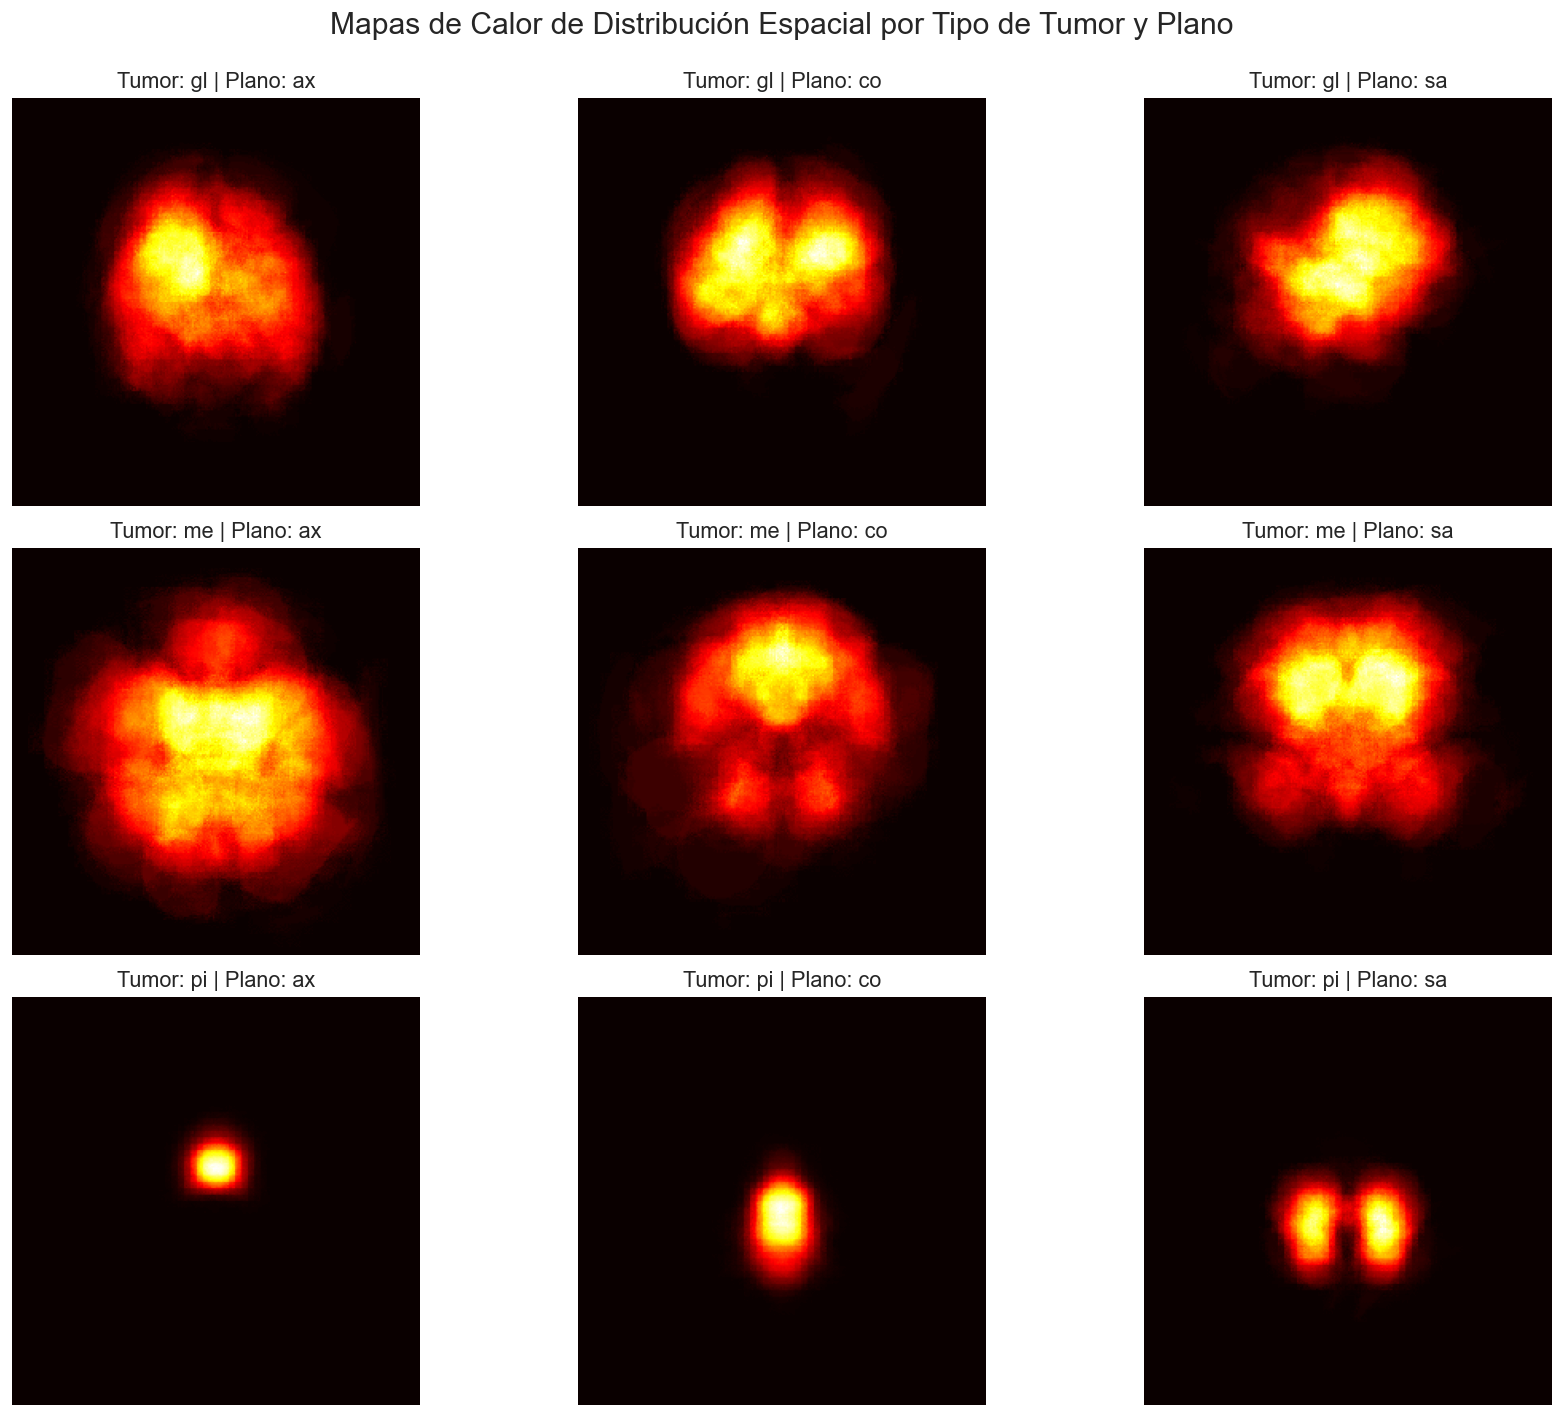

In [90]:

def generate_heatmaps(df, base_path, target_size=(256, 256)):
    tumors = df['tumor'].unique()
    views = df['view'].unique()
    
    fig, axes = plt.subplots(len(tumors), len(views), figsize=(15, 12))
    
    for i, tumor in enumerate(sorted(tumors)):
        for j, view in enumerate(sorted(views)):
            subset = df[(df['tumor'] == tumor) & (df['view'] == view)]
            
            accumulated_mask = np.zeros(target_size, dtype=np.float32)
            
            for _, row in subset.iterrows():
                m_path = os.path.join(base_path, "segmentation_task", row["split"], "masks", row["filename"].replace(".jpg", ".png"))
                mask = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
                if mask is not None:
                    mask_res = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
                    accumulated_mask += (mask_res > 0)
            
            if len(subset) > 0:
                accumulated_mask /= len(subset)
            
            im = axes[i, j].imshow(accumulated_mask, cmap='hot')
            axes[i, j].set_title(f"Tumor: {tumor} | Plano: {view}")
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    fig.suptitle('Mapas de Calor de Distribución Espacial por Tipo de Tumor y Plano', fontsize=18)
    plt.show()

generate_heatmaps(df, base_path)

**Patrones observados:**

- **Pituitary (pi):** Presenta la mayor focalización espacial, con densidad concentrada en la línea media en cortes coronales y región central inferior en sagitales, correspondiente a la localización anatómica de la silla turca.

- **Meningioma (me):** Distribución bilateral en plano coronal, típica de tumores parasagitales y de convexidad. En sagital, abarca desde región frontal a occipital, consistente con su origen extra-axial.

- **Glioma (gl):** Patrón unilateral difuso en axial, con afectación de sustancia blanca profunda. En sagital, predomina en regiones anteriores y medias.

### **3.7 Análisis de perfiles de intensidad y contraste**

En imágenes de Resonancia Magnética (MRI), el éxito de la segmentación depende de la diferencia de contraste entre el tejido patológico y el tejido sano circundante. Dado que trabajamos con secuencias T1, es vital entender el rango dinámico de los valores de gris (0-255).

Este análisis permite determinar:
1.  **Necesidad de Normalización:** Si los histogramas varían mucho entre imágenes, se justifica el uso de **Z-score normalization** o **Min-Max scaling**.
2.  **Separabilidad Lineal:** Observar si el tumor tiene una firma de intensidad distinta al resto del cerebro o si el ruido de fondo es significativo.

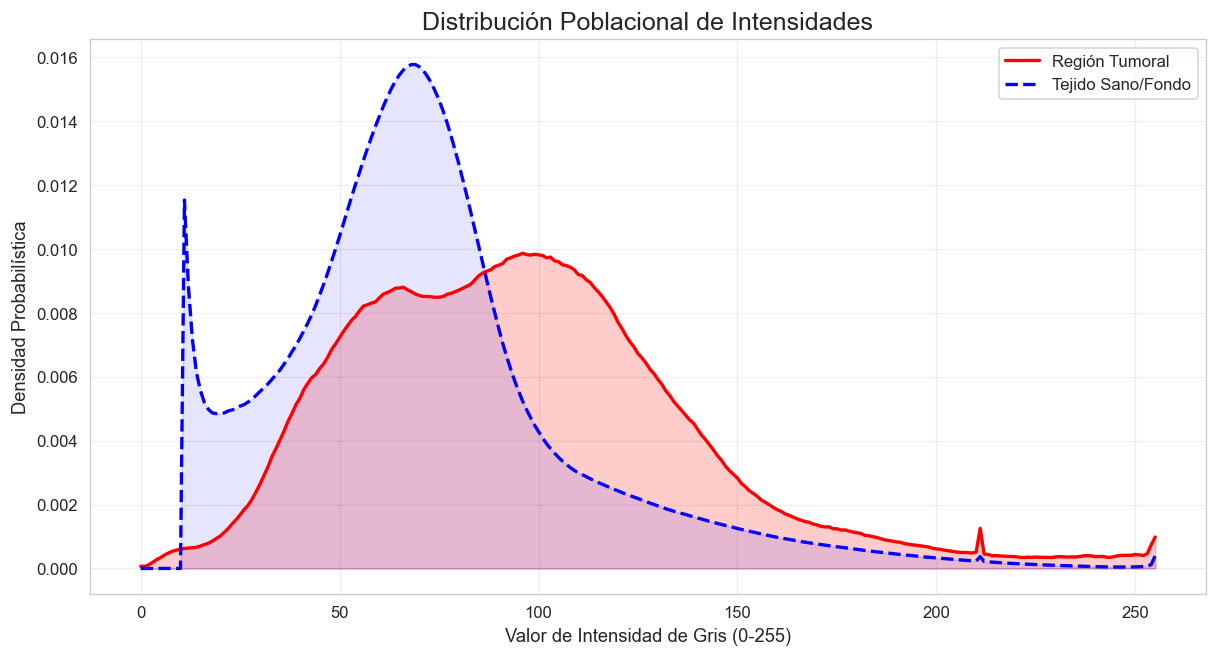

In [91]:
def plot_full_intensity_distribution(df, base_path):
    all_tumor_hist = np.zeros(256, dtype=np.float64)
    all_background_hist = np.zeros(256, dtype=np.float64)

    for idx, row in df.iterrows():
        img_path = os.path.join(base_path, "segmentation_task", row["split"], "images", row["filename"])
        mask_path = os.path.join(base_path, "segmentation_task", row["split"], "masks", row["filename"].replace(".jpg", ".png"))
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None and mask is not None:

            is_tumor = mask > 0
            is_background = (mask == 0) & (img > 10)
            
            all_tumor_hist += np.histogram(img[is_tumor], bins=256, range=(0, 255))[0]
            all_background_hist += np.histogram(img[is_background], bins=256, range=(0, 255))[0]
    

    all_tumor_hist /= all_tumor_hist.sum()
    all_background_hist /= all_background_hist.sum()

    plt.figure(figsize=(12, 6))
    plt.plot(all_tumor_hist, label="Región Tumoral", color='red', linewidth=2)
    plt.plot(all_background_hist, label="Tejido Sano/Fondo", color='blue', linewidth=2, linestyle='--')
    
    plt.fill_between(range(256), all_tumor_hist, color='red', alpha=0.2)
    plt.fill_between(range(256), all_background_hist, color='blue', alpha=0.1)

    plt.title("Distribución Poblacional de Intensidades", fontsize=15)
    plt.xlabel("Valor de Intensidad de Gris (0-255)")
    plt.ylabel("Densidad Probabilística")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_full_intensity_distribution(df, base_path)

La imagen muestra la distribución de intensidades de píxeles para región tumoral y tejido sano en todo el dataset (4,793 pares imagen-máscara).

**Observaciones principales:**

- **Solapamiento significativo:** Ambas distribuciones presentan un rango dinámico similar, con máximos de densidad entre 50 y 150 unidades de gris. No existe un umbral de intensidad que permita separar tumor de tejido sano de manera directa.

- **Cola inferior:** La región tumoral muestra menor densidad en valores bajos (<30), mientras que el tejido sano presenta un pico adicional en esta zona, correspondiente a estructuras como líquido cefalorraquídeo y espacios ventriculares.

- **Distribución unimodal:** Ambas curvas son unimodales, indicando que el contraste entre tejido patológico y sano en secuencias T1 es sutil y requiere características contextuales para una segmentación precisa.

### **3.8 Análisis de Consistencia entre Particiones**

Un aspecto crítico en la metodología de investigación es garantizar que no exista un sesgo significativo entre el conjunto de entrenamiento y el de prueba. Si las imágenes de prueba fueran sistemáticamente más brillantes, más grandes o con tumores de distinto tamaño que las de entrenamiento, los resultados del modelo no serían fiables.

Para validar la homogeneidad del dataset, realizamos una comparación estadística de la intensidad media de los píxeles y el área tumoral entre las particiones `train` y `test`. Utilizaremos la prueba no paramétrica de **Mann-Whitney U**, la cual es robusta y no asume una distribución normal de los datos, para determinar si existen diferencias significativas ($p < 0.05$).


1. Área Tumoral:
   p-valor = 0.5183
   Resultado: Particiones homogéneas

2. Intensidad Media (Brillo):
   p-valor = 0.0026
   Resultado: Diferencia significativa


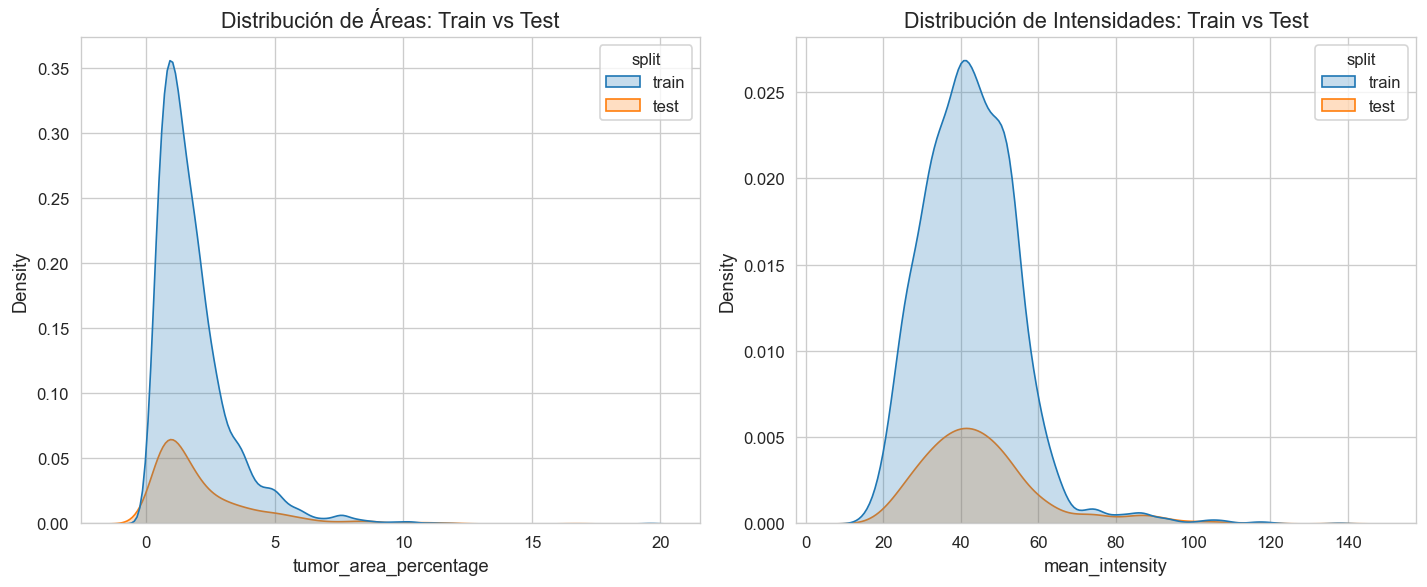

In [94]:
def perform_homogeneity_test(df):
    
    train_areas = df[df['split'] == 'train']['tumor_area_percentage']
    test_areas = df[df['split'] == 'test']['tumor_area_percentage']
    
    u_stat_area, p_val_area = stats.mannwhitneyu(train_areas, test_areas)
    
    def get_mean_intensity(row):
        img_path = os.path.join(base_path, "segmentation_task", row["split"], "images", row["filename"])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        return np.mean(img) if img is not None else 0

    df['mean_intensity'] = df.apply(get_mean_intensity, axis=1)
    
    train_ints = df[df['split'] == 'train']['mean_intensity']
    test_ints = df[df['split'] == 'test']['mean_intensity']
    
    u_stat_int, p_val_int = stats.mannwhitneyu(train_ints, test_ints)
    
    print(f"\n1. Área Tumoral:")
    print(f"   p-valor = {p_val_area:.4f}")
    print("   Resultado: " + ("Diferencia significativa" if p_val_area < 0.05 else "Particiones homogéneas"))
    
    print(f"\n2. Intensidad Media (Brillo):")
    print(f"   p-valor = {p_val_int:.4f}")
    print("   Resultado: " + ("Diferencia significativa" if p_val_int < 0.05 else "Particiones homogéneas"))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.kdeplot(data=df, x='tumor_area_percentage', hue='split', fill=True)
    plt.title("Distribución de Áreas: Train vs Test")
    
    plt.subplot(1, 2, 2)
    sns.kdeplot(data=df, x='mean_intensity', hue='split', fill=True)
    plt.title("Distribución de Intensidades: Train vs Test")
    
    plt.tight_layout()
    plt.show()

perform_homogeneity_test(df)

| **Métrica** | **p-valor** | **Resultado** |
|-------------|-------------|---------------|
| Área Tumoral | 0.5183 | Homogéneo |
| Intensidad Media | 0.0026 | Diferencia significativa |

- **Área tumoral:** No se detectan diferencias significativas entre particiones (p > 0.05). La distribución del tamaño de los tumores es consistente, lo que garantiza que la evaluación del modelo no estará sesgada por esta variable.

- **Intensidad media:** Se observa una diferencia estadísticamente significativa (p < 0.05) entre la intensidad media de las imágenes en train y test. La visualización sugiere que las imágenes de prueba presentan sistemáticamente valores de brillo ligeramente inferiores.

**Implicaciones para el modelado:** La diferencia en intensidad refuerza la necesidad de aplicar **normalización por imagen** (Z-score o Min-Max) en el preprocesamiento, en lugar de una normalización global. Este enfoque mitigará las diferencias de brillo entre particiones y mejorará la capacidad de generalización del modelo.

### **3.9 Conclusiones del EDA e Implicaciones para el Modelado**

Tras el análisis exploratorio del dataset BRISC 2025, se han identificado patrones clave que sugieren las siguientes estrategias para la etapa de modelado:

1.  **Estandarización de dimensiones:** Debido a que el dataset presenta una variabilidad considerable en las resoluciones originales (entre 200 y 600 píxeles), se propone evaluar un redimensionamiento estándar a **256x256 píxeles**. Esta transformación permitiría la compatibilidad con arquitecturas convolucionales clásicas, aunque deberá analizarse si la deformación anatómica resultante afecta la precisión en estructuras pequeñas.
2.  **Estrategia frente al sesgo de intensidad:** El hallazgo de una diferencia estadísticamente significativa en el brillo medio entre *train* y *test* ($p = 0.0026$) sugiere que una normalización global podría ser insuficiente. Como posible solución, se plantea el uso de **normalización Z-score por instancia**, procesando cada imagen de forma independiente para intentar mitigar este desbalance y mejorar la estabilidad del aprendizaje.
3.  **Abordaje del desbalance de píxeles (Sparsity):** Con una carga tumoral media de apenas el **1.88%**, el problema se perfila como una tarea de segmentación de objetos pequeños. Bajo este escenario, es probable que funciones de pérdida basadas en la superposición espacial, como **Dice Loss o variantes de Tversky**, ofrezcan una señal de gradiente más útil que la entropía cruzada convencional, punto que deberá ser validado empíricamente.
4.  **Aumentación de datos y robustez espacial:** Los mapas de calor revelaron que los tumores tienden a concentrarse en regiones específicas según su categoría. Para evitar que el modelo genere un sesgo de localización, consideraremos técnicas de **Data Augmentation** (rotaciones, traslaciones y espejados). El objetivo sería forzar a la red a identificar texturas y formas en lugar de depender de la ubicación absoluta de los píxeles.